# Lab 3 — Detección de anomalías con Machine Learning

**Autor:** David Robert Yucra Mamani  
**Curso:** Seguridad Informática  
**Modelo:** Isolation Forest  

El dataset se lee desde `lab3/network_traffic.csv`. La columna `label` se usa **solo para validación**, no para entrenamiento.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

BASE_DIR = Path.cwd()
if BASE_DIR.name != 'lab3':
    # Permite ejecutar desde la raiz del repositorio o desde lab3/
    DATA_PATH = BASE_DIR / 'lab3' / 'network_traffic.csv'
    MODEL_PATH = BASE_DIR / 'lab3' / 'modelo_anomalias.pkl'
else:
    DATA_PATH = BASE_DIR / 'network_traffic.csv'
    MODEL_PATH = BASE_DIR / 'modelo_anomalias.pkl'

print('Dataset:', DATA_PATH)

Dataset: /home/ubuntu/examen-practico-yucra-mamani/lab3/network_traffic.csv


## 3.1 Exploración y preprocesamiento

In [3]:
df = pd.read_csv(DATA_PATH)

print('Dimensiones:', df.shape)

display(df.head())

display(df.describe(include='all'))

print('\nValores nulos por columna:')
print(df.isna().sum())

Dimensiones: (10000, 10)


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
0,2024-05-26 04:28:31,10.0.2.118,201.250.32.133,21,TCP,15310,45067,42.01,16,normal
1,2024-05-11 01:38:15,10.0.1.189,193.199.92.89,21,UDP,3692990,68116,55.35,2823,normal
2,2024-05-17 21:00:41,10.0.3.254,202.222.194.7,443,ICMP,23007,950555,6.64,18,normal
3,2024-05-09 18:30:38,10.0.1.254,152.183.142.33,25,TCP,467423,56148,3.12,656,normal
4,2024-05-27 17:50:29,10.0.3.87,64.39.138.32,3306,UDP,15355,18895,16.82,23,normal


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
count,10000,10000,10000,10000.000000,10000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04,10000
unique,9985,34,277,NaN,3,NaN,NaN,NaN,NaN,2
top,2024-05-08 23:16:57,10.0.1.180,10.0.3.174,NaN,TCP,NaN,NaN,NaN,NaN,normal
freq,2,719,282,NaN,6984,NaN,NaN,NaN,NaN,9500
mean,NaN,NaN,NaN,5272.963700,NaN,2.815289e+07,4.124360e+05,447.154662,1.605501e+04,NaN
std,NaN,NaN,NaN,7348.395782,NaN,3.115671e+08,1.964278e+06,4530.488171,1.672859e+05,NaN
min,NaN,NaN,NaN,21.000000,NaN,1.500000e+01,0.000000e+00,0.000000,1.000000e+00,NaN
25%,NaN,NaN,NaN,53.000000,NaN,5.544000e+03,1.328800e+04,8.507500,5.000000e+00,NaN
50%,NaN,NaN,NaN,3389.000000,NaN,2.233900e+04,5.529050e+04,21.435000,2.400000e+01,NaN
75%,NaN,NaN,NaN,8080.000000,NaN,9.478175e+04,2.213258e+05,44.145000,1.100000e+02,NaN



Valores nulos por columna:
timestamp       0
src_ip          0
dst_ip          0
dst_port        0
protocol        0
bytes_sent      0
bytes_recv      0
duration_sec    0
packets         0
label           0
dtype: int64


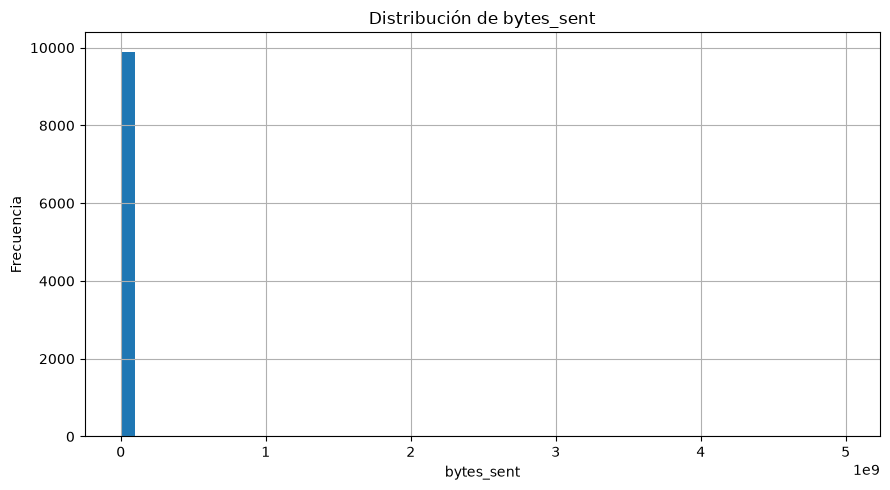

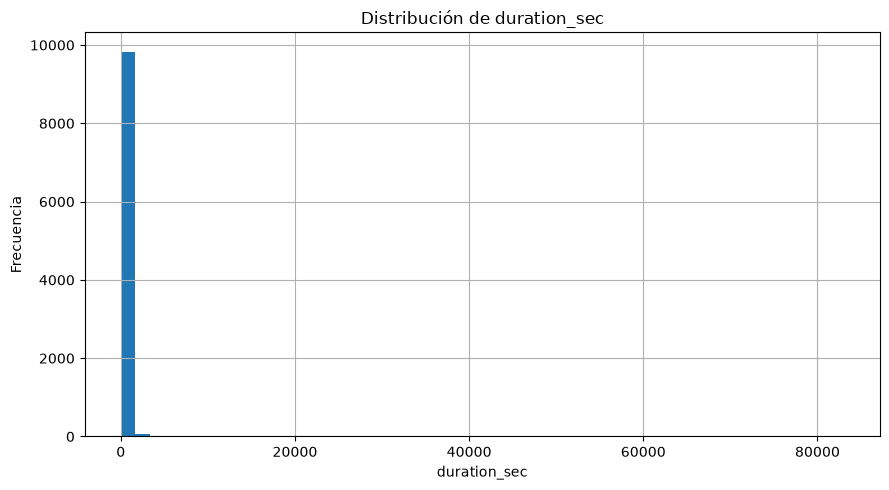

In [4]:
# Histogramas solicitados: bytes_sent y duration_sec
plt.figure(figsize=(9,5))
df['bytes_sent'].hist(bins=50)
plt.title('Distribución de bytes_sent')
plt.xlabel('bytes_sent')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
df['duration_sec'].hist(bins=50)
plt.title('Distribución de duration_sec')
plt.xlabel('duration_sec')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [5]:
# Copia de trabajo y conversiones
work = df.copy()
work['timestamp'] = pd.to_datetime(work['timestamp'], errors='coerce')

# Columnas numéricas base
numeric_base = ['dst_port', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets']
for col in numeric_base:
    work[col] = pd.to_numeric(work[col], errors='coerce')
    work[col] = work[col].fillna(work[col].median())

# Tratamiento simple de atípicos extremos: clipping entre percentiles 1 y 99
clip_bounds = {}
for col in numeric_base:
    q01, q99 = work[col].quantile([0.01, 0.99])
    clip_bounds[col] = (float(q01), float(q99))
    work[col] = work[col].clip(q01, q99)

# Feature engineering solicitado: al menos 2 variables derivadas
work['hour'] = work['timestamp'].dt.hour.fillna(0)
work['dayofweek'] = work['timestamp'].dt.dayofweek.fillna(0)
work['ratio_bytes'] = work['bytes_sent'] / (work['bytes_recv'] + 1)
work['bytes_por_segundo'] = (work['bytes_sent'] + work['bytes_recv']) / (work['duration_sec'] + 1)
work['packets_por_segundo'] = work['packets'] / (work['duration_sec'] + 1)

# One-hot encoding del protocolo
protocol_dummies = pd.get_dummies(work['protocol'].fillna('UNKNOWN'), prefix='protocol')
features = pd.concat([
    work[['dst_port','bytes_sent','bytes_recv','duration_sec','packets','hour','dayofweek','ratio_bytes','bytes_por_segundo','packets_por_segundo']],
    protocol_dummies
], axis=1)

features = features.replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print('Features usadas para entrenamiento:', list(features.columns))
print('Matriz normalizada:', X_scaled.shape)

Features usadas para entrenamiento: ['dst_port', 'bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'hour', 'dayofweek', 'ratio_bytes', 'bytes_por_segundo', 'packets_por_segundo', 'protocol_ICMP', 'protocol_TCP', 'protocol_UDP']
Matriz normalizada: (10000, 13)


## 3.2 Entrenamiento del modelo y métricas

Precision: 0.6180
Recall:    0.6180
F1-Score:  0.6180
Reporte de clasificación:
              precision    recall  f1-score   support

     anomaly       0.62      0.62      0.62       500
      normal       0.98      0.98      0.98      9500

    accuracy                           0.96     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.96      0.96      0.96     10000



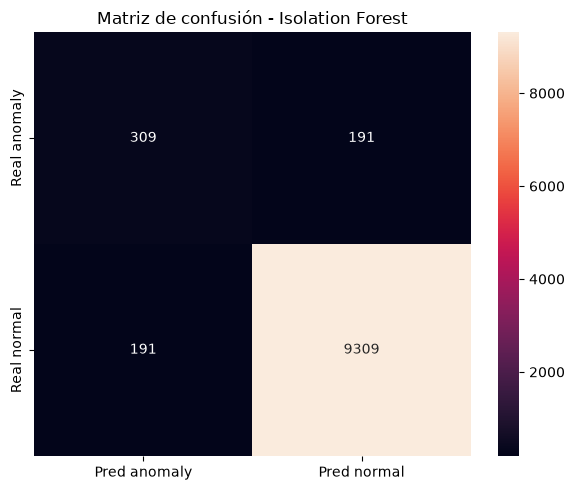

In [7]:
# Entrenamiento sin usar label
model = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
model.fit(X_scaled)

pred = model.predict(X_scaled)  # -1 = anomalía, 1 = normal

# Validación con label solo después del entrenamiento
label_map = {'anomaly': -1, 'normal': 1, 'anomalia': -1, 'normal': 1}
y_true = work['label'].astype(str).str.lower().map(label_map)
if y_true.isna().any():
    print('Advertencia: existen labels no reconocidos. Valores:', work['label'].unique())
    y_true = y_true.fillna(1)
y_true = y_true.astype(int)

precision = precision_score(y_true, pred, pos_label=-1, zero_division=0)
recall = recall_score(y_true, pred, pos_label=-1, zero_division=0)
f1 = f1_score(y_true, pred, pos_label=-1, zero_division=0)

print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print('Reporte de clasificación:')
print(classification_report(y_true, pred, labels=[-1,1], target_names=['anomaly','normal'], zero_division=0))

cm = confusion_matrix(y_true, pred, labels=[-1, 1])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Pred anomaly','Pred normal'], yticklabels=['Real anomaly','Real normal'])
plt.title('Matriz de confusión - Isolation Forest')
plt.tight_layout()
plt.show()

## 3.3 Interpretación y umbral dinámico

En Isolation Forest, los valores más bajos del `decision_function` suelen indicar mayor anomalía.

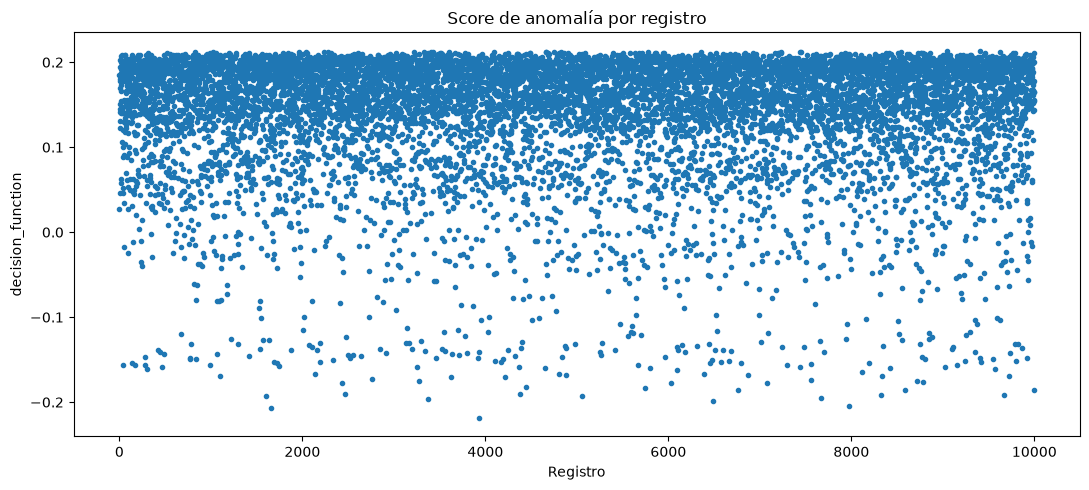

In [8]:
scores = model.decision_function(X_scaled)
work['score_anomalia'] = scores
work['prediccion_base'] = pred

plt.figure(figsize=(11,5))
plt.plot(scores, marker='.', linewidth=0)
plt.title('Score de anomalía por registro')
plt.xlabel('Registro')
plt.ylabel('decision_function')
plt.tight_layout()
plt.show()

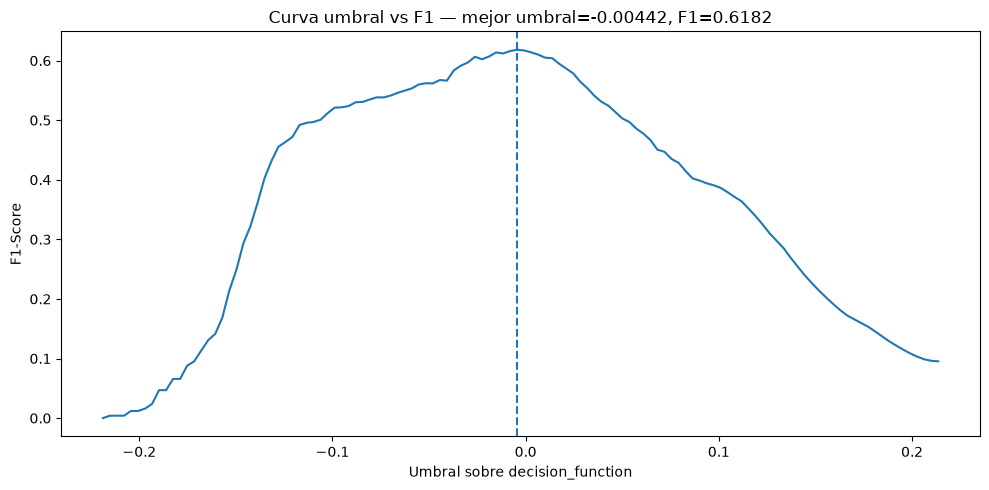

Mejor umbral: -0.004424681713850076
Mejor F1: 0.6182190378710338


In [9]:
thresholds = np.linspace(scores.min(), scores.max(), 120)
f1_values = []
for th in thresholds:
    pred_th = np.where(scores < th, -1, 1)
    f1_values.append(f1_score(y_true, pred_th, pos_label=-1, zero_division=0))

best_idx = int(np.argmax(f1_values))
best_threshold = float(thresholds[best_idx])
best_f1 = float(f1_values[best_idx])

plt.figure(figsize=(10,5))
plt.plot(thresholds, f1_values)
plt.axvline(best_threshold, linestyle='--')
plt.title(f'Curva umbral vs F1 — mejor umbral={best_threshold:.5f}, F1={best_f1:.4f}')
plt.xlabel('Umbral sobre decision_function')
plt.ylabel('F1-Score')
plt.tight_layout()
plt.show()

print('Mejor umbral:', best_threshold)
print('Mejor F1:', best_f1)

In [10]:
# Top 10 registros más anómalos: menor score
cols_mostrar = list(df.columns) + ['score_anomalia', 'prediccion_base']
top10_anomalias = work.sort_values('score_anomalia').head(10)[cols_mostrar]
display(top10_anomalias)

,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label,score_anomalia,prediccion_base
3935,2024-05-02 05:32:06,10.0.1.206,76.196.246.10,80,ICMP,9.992469e+06,230.0,1.10,67206.00,anomaly,-0.218781,-1
1652,2024-05-22 04:24:05,10.0.1.83,134.254.60.66,53,ICMP,8.746305e+06,11.0,7.41,76098.00,anomaly,-0.207368,-1
7979,2024-05-06 04:16:50,10.0.2.118,162.247.74.201,443,ICMP,7.896912e+06,89.0,24.24,80643.00,anomaly,-0.204519,-1
6493,2024-05-29 23:40:17,10.0.3.25,94.184.124.134,80,UDP,5.077456e+06,306.0,1.04,79228.00,anomaly,-0.198548,-1
3373,2024-05-30 07:17:09,10.0.1.114,185.220.101.45,53,UDP,9.687834e+06,391.0,5.00,80654.00,anomaly,-0.195810,-1
7663,2024-05-16 16:37:46,10.0.1.97,23.129.64.214,53,UDP,9.981411e+06,324.0,6.15,78889.00,anomaly,-0.195198,-1
5058,2024-05-05 10:16:01,10.0.3.101,61.47.234.82,53,UDP,7.440598e+06,10.0,5.95,57096.00,anomaly,-0.193188,-1
1599,2024-05-13 17:45:48,10.0.3.101,90.104.72.227,443,TCP,5.523770e+06,152.0,4.30,91119.00,anomaly,-0.192657,-1
9667,2024-05-14 18:52:35,10.0.1.254,14.125.240.42,80,TCP,6.978062e+06,155.0,1.39,84490.00,anomaly,-0.191831,-1
8322,2024-05-07 02:28:18,10.0.3.75,143.109.217.176,8080,ICMP,2.768903e+07,12306.0,3330.27,100808.23,anomaly,-0.191782,-1


### Interpretación de posibles amenazas

Los registros del Top 10 pueden representar una amenaza real cuando combinan uno o varios de estos factores:

- `bytes_sent` demasiado alto frente a `bytes_recv`, lo que puede sugerir exfiltración de datos.
- `duration_sec` muy corto con muchos paquetes, posible automatización o escaneo.
- Puertos de destino poco comunes o sensibles.
- Comunicación fuera del patrón normal del tráfico de la red.
- Alta tasa `bytes_por_segundo` o `packets_por_segundo`, que puede indicar transferencia masiva o comportamiento anómalo.

## 3.4 Exportación del modelo

In [11]:
paquete_modelo = {
    'model': model,
    'scaler': scaler,
    'feature_columns': list(features.columns),
    'threshold': best_threshold,
    'clip_bounds': clip_bounds,
    'nota': 'Modelo Isolation Forest para detección de anomalías. -1=anomalia, 1=normal.'
}
joblib.dump(paquete_modelo, MODEL_PATH)
print('Modelo guardado en:', MODEL_PATH)

Modelo guardado en: /home/ubuntu/examen-practico-yucra-mamani/lab3/modelo_anomalias.pkl


## Prueba del script `predecir.py`

Desde terminal:

```bash
cd examen-practico-yucra
source .venv/bin/activate
python lab3/predecir.py lab3/nuevo_trafico.csv
```